# Phase 2: Data Threshing Pipeline
## FIT Machine Implementation

**Goal:** Clean FER2013 dataset using:
- Face detection filtering
- Quality assessment (brightness, contrast, blur)
- Class balancing

In [1]:
# Install required packages (run once)
import sys
!{sys.executable} -m pip install typing_extensions --upgrade --quiet
!{sys.executable} -m pip install torch torchvision --quiet
!{sys.executable} -m pip install opencv-python scikit-learn scikit-image pillow --quiet
!{sys.executable} -m pip install facenet-pytorch --quiet
print("✓ All packages installed!")

✓ All packages installed!


In [2]:
import sys
sys.path.append('..')

import numpy as np
import cv2
import pickle
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

from src.utils.config import Config, setup_seed
from src.utils.visualization import plot_data_threshing_results, plot_class_distribution
from src.data.dataset_loader import FER2013Dataset
from src.data.data_thresher import DataThresher

config = Config('../config/config.yaml')
setup_seed(config.get('project.random_seed'))
emotions = config.get('emotions.classes')

%matplotlib inline
print('✓ Setup complete!')

✓ Setup complete!


## 1. Load Original Dataset

In [3]:
print('Loading FER2013...')
PROJECT_ROOT = Path('..').resolve()
fer_path = str(PROJECT_ROOT / config.get('data.fer2013.path'))
fer_train = FER2013Dataset(fer_path, split='train')
print(f'✓ Loaded {len(fer_train)} samples')

original_dist = {}
for i, emotion in enumerate(emotions):
    count = fer_train.labels.count(i)
    original_dist[emotion] = count
    print(f'  {emotion}: {count}')


Loading FER2013...
Loading from: /Users/nyanwaiphyo/Signature Project/fer-project/data/raw/FER2013/train


Loaded 28709 images from /Users/nyanwaiphyo/Signature Project/fer-project/data/raw/FER2013/train
✓ Loaded 28709 samples
  angry: 3995
  disgust: 436
  fear: 4097
  happy: 7215
  sad: 4830
  surprise: 3171
  neutral: 4965


## 2. Initialize Data Thresher

In [4]:
thresher = DataThresher(config)

print('Threshing Configuration:')
print(f"  Face confidence: {config.get('threshing.face_detection.min_confidence')}")
print(f"  Min brightness: {config.get('threshing.quality.min_brightness')}")
print(f"  Max brightness: {config.get('threshing.quality.max_brightness')}")
print(f"  Min contrast: {config.get('threshing.quality.min_contrast')}")
print(f"  Blur threshold: {config.get('threshing.quality.blur_threshold')}")

Threshing Configuration:
  Face confidence: 0.0
  Min brightness: 5
  Max brightness: 250
  Min contrast: 0.01
  Blur threshold: 5


## 3. Apply Data Threshing

⚠️ **This takes 10-30 minutes!**

In [5]:
print('Starting data threshing...')
print('⚠️  This may take 10-30 minutes\n')

filtered_images, filtered_labels, stats = thresher.filter_dataset(
    fer_train.images,
    fer_train.labels,
    class_names=emotions
)

print('\n✓ Threshing complete!')

Starting data threshing...
⚠️  This may take 10-30 minutes

Starting data threshing pipeline...


Threshing data: 100%|████████████████████| 28709/28709 [03:09<00:00, 151.43it/s]


Data Threshing Results:
Total samples before: 28709
Total samples after:  23461
Samples removed:      5248 (18.3%)

Removal reasons:
  no_face: 3567
  low_brightness: 0
  low_contrast: 0
  too_blurry: 1260
  multiple_issues: 421


✓ Threshing complete!


## 4. Analyze Results

/Users/nyanwaiphyo/Signature Project/fer-project/notebooks/../src/utils/visualization.py:265: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(classes, rotation=45, ha='right')


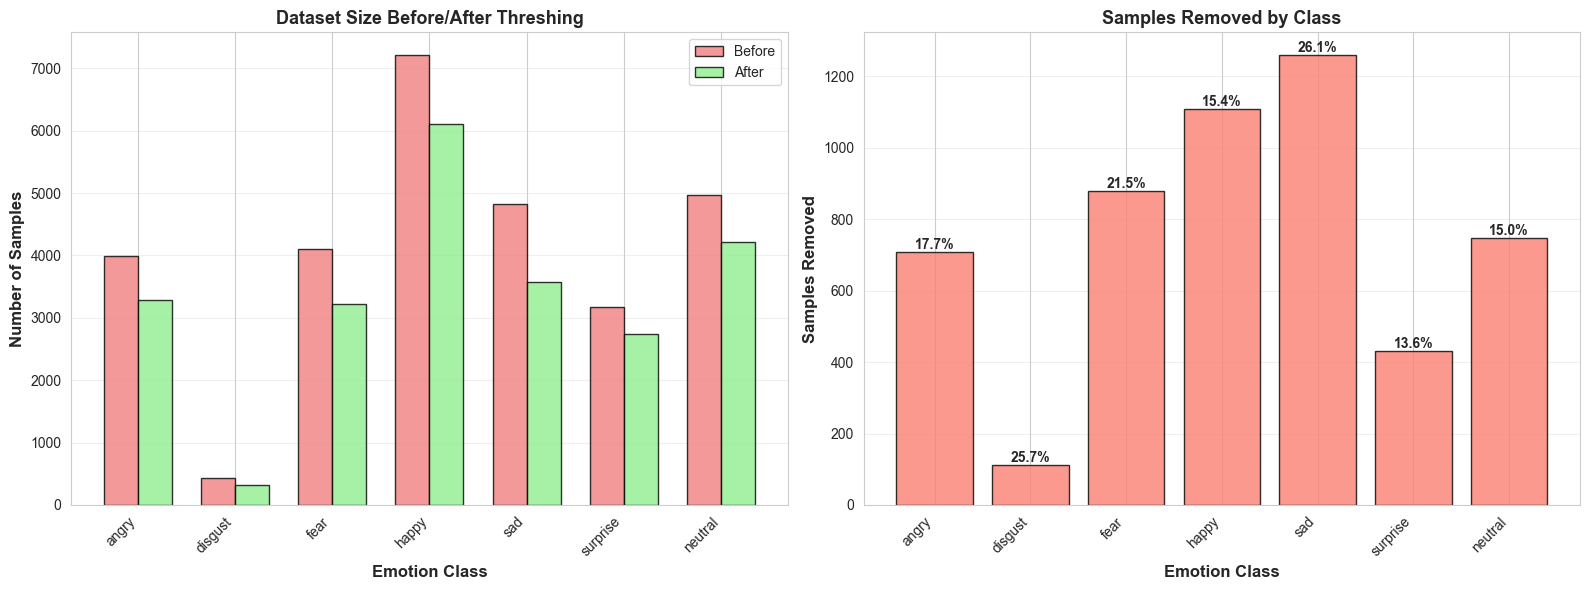

angry: 3995 → 3286 (removed 709, 17.7%)
disgust: 436 → 324 (removed 112, 25.7%)
fear: 4097 → 3217 (removed 880, 21.5%)
happy: 7215 → 6107 (removed 1108, 15.4%)
sad: 4830 → 3570 (removed 1260, 26.1%)
surprise: 3171 → 2739 (removed 432, 13.6%)
neutral: 4965 → 4218 (removed 747, 15.0%)


In [6]:
filtered_dist = {e: stats['class_stats'][e]['after'] for e in emotions}
removed_dist = {e: stats['class_stats'][e]['removed'] for e in emotions}

plot_data_threshing_results(original_dist, filtered_dist, removed_dist,
    save_path='../outputs/figures/threshing_results.png')
plt.show()

for emotion in emotions:
    before, after, removed = original_dist[emotion], filtered_dist[emotion], removed_dist[emotion]
    pct = (removed / before * 100) if before > 0 else 0
    print(f'{emotion}: {before} → {after} (removed {removed}, {pct:.1f}%)')

## 5. Class Balancing

Balancing classes (max 5000 per class)...
Balanced dataset size: 22354


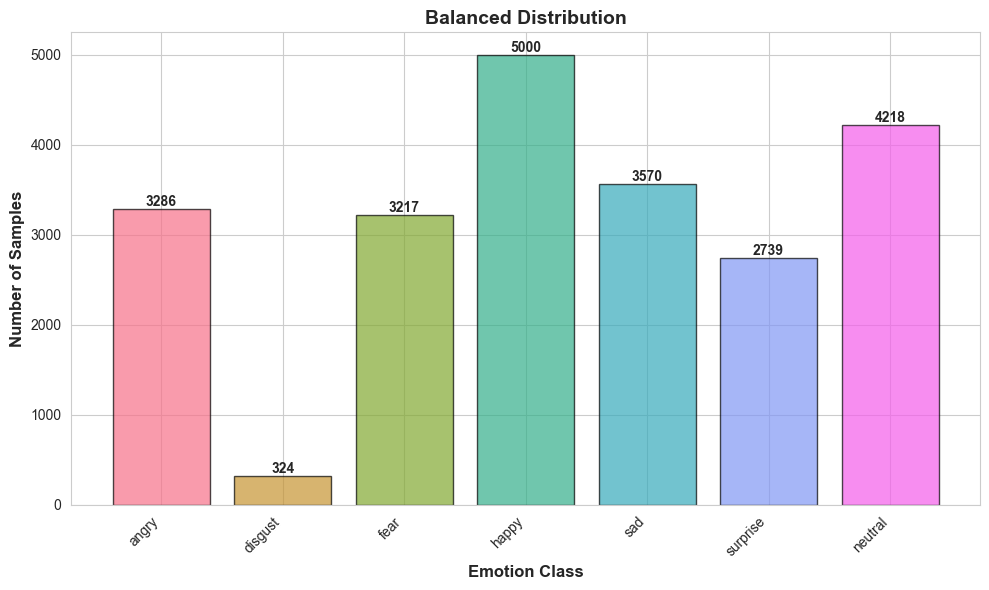

Final dataset: 22354 samples


In [7]:
if config.get('threshing.balance.enable_undersampling'):
    balanced_images, balanced_labels = thresher.balance_classes(
        filtered_images, filtered_labels,
        max_samples_per_class=config.get('threshing.balance.max_samples_per_class'))
    balanced_dist = {emotions[i]: balanced_labels.count(i) for i in range(len(emotions))}
    plot_class_distribution(balanced_dist, 'Balanced Distribution',
        save_path='../outputs/figures/balanced_distribution.png')
    plt.show()
    final_images, final_labels = balanced_images, balanced_labels
else:
    final_images, final_labels = filtered_images, filtered_labels

print(f'Final dataset: {len(final_images)} samples')

## 6. Save Cleaned Dataset

In [8]:
output_dir = Path('../data/processed/fer2013_cleaned')
output_dir.mkdir(parents=True, exist_ok=True)

for emotion in emotions:
    (output_dir / emotion).mkdir(exist_ok=True)

emotion_counters = {i: 0 for i in range(len(emotions))}
for img, label in tqdm(zip(final_images, final_labels), total=len(final_images)):
    emotion_name = emotions[label]
    filename = f'{emotion_name}_{emotion_counters[label]:05d}.png'
    cv2.imwrite(str(output_dir / emotion_name / filename), img)
    emotion_counters[label] += 1

pickle_path = output_dir / 'cleaned_dataset.pkl'
with open(pickle_path, 'wb') as f:
    pickle.dump({'images': final_images, 'labels': final_labels, 
                'emotions': emotions, 'stats': stats}, f)

print(f'✓ Saved to: {output_dir}')
print(f'✓ Pickle: {pickle_path}')
print('\n✓ Phase 2 Complete!')

100%|███████████████████████████████████| 22354/22354 [00:15<00:00, 1454.48it/s]


✓ Saved to: ../data/processed/fer2013_cleaned
✓ Pickle: ../data/processed/fer2013_cleaned/cleaned_dataset.pkl

✓ Phase 2 Complete!
